# Prepare Tissue Representations

In [11]:
import h5py
import numpy as np
import pickle

In [12]:
pge_path = 'colon_nct_feature/pge_dim_reduced_feature.h5'
resnet50_path = 'colon_nct_feature/resnet50_dim_reduced_feature.h5'
inceptionv3_path = 'colon_nct_feature/inceptionv3_dim_reduced_feature.h5'
vgg16_path = 'colon_nct_feature/vgg16_dim_reduced_feature.h5'

pge_content = h5py.File(pge_path, mode='r')
resnet50_content = h5py.File(resnet50_path, mode='r')
inceptionv3_content = h5py.File(inceptionv3_path, mode='r')
vgg16_content = h5py.File(vgg16_path, mode='r')

In [13]:
vgg16_content

<HDF5 file "vgg16_dim_reduced_feature.h5" (mode r)>

In [14]:
#PCA feature from 4 feature sets: pge_latent, resnet50_latent, inceptionv3_latent, vgg16_latent
pge_pca_feature  = pge_content['pca_feature'][...]
resnet50_pca_feature  = resnet50_content['pca_feature'][...]
inceptionv3_pca_feature = inceptionv3_content['pca_feature'][...]
vgg16_pca_feature  = vgg16_content['pca_feature'][...]

In [15]:
vgg16_pca_feature

array([[ -90.864815 ,  107.03243  ,  116.16385  , ...,    8.259951 ,
          -1.1383446,   -9.175951 ],
       [ -74.06226  ,  117.31615  ,   95.24547  , ...,   -1.9739974,
           6.8172655,    4.2547903],
       [ -81.875336 ,  122.84872  ,   83.767784 , ...,   -1.3287221,
          13.65623  ,  -11.109545 ],
       ...,
       [  32.70835  ,   31.183935 ,  -47.30978  , ...,    4.2004256,
           3.599823 ,    6.0058775],
       [ -39.911785 , -105.81029  ,  122.37118  , ...,  -14.908715 ,
          -1.1814455,  -10.837135 ],
       [  32.35425  ,  -50.3373   ,   66.50197  , ...,   -3.859397 ,
          -1.047523 ,    2.3827858]], dtype=float32)

In [16]:
#UMAP feature from 4 feature sets: pge_latent, resnet50_latent, inceptionv3_latent, vgg16_latent
pge_umap_feature  = pge_content['umap_feature'][...]
resnet50_umap_feature = resnet50_content['umap_feature'][...]
inceptionv3_umap_feature  = inceptionv3_content['umap_feature'][...]
vgg16_umap_feature  = vgg16_content['umap_feature'][...]

In [17]:
#tissue type as available ground-truth: labels
filename  = np.squeeze(pge_content['file_name'])
filename = np.array([str(x) for x in filename])
labels = np.array([x.split('/')[2] for x in filename])
labels

array(['ADI', 'ADI', 'ADI', ..., 'TUM', 'TUM', 'TUM'], dtype='<U4')

In [18]:
print(len(set(labels)))

9


# Using K-Means 

out put silhouette and v_measure of K-means clustering and visualized the percentage of members with different labels within each cluster

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, v_measure_score
import os

Cluster 0: 551 samples
Cluster 1: 675 samples
Cluster 2: 386 samples
Cluster 3: 949 samples
Cluster 4: 585 samples
Cluster 5: 104 samples
Cluster 6: 121 samples
Cluster 7: 669 samples
Cluster 8: 960 samples


D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


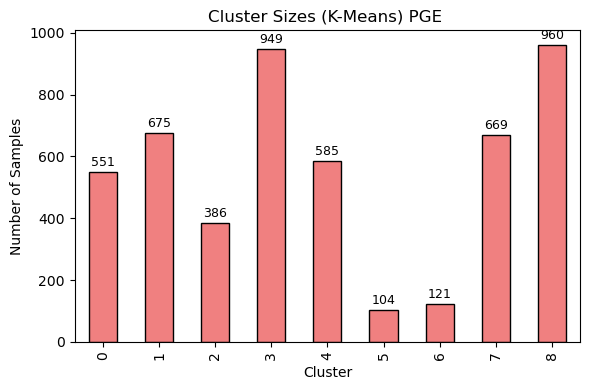

       Metric     Score
0  Silhouette  0.531303
1   V-measure  0.552426


In [50]:
os.environ["OMP_NUM_THREADS"] = "20"

# set number of clusters = 9
kmeans = KMeans(n_clusters=9, random_state=42)
clusters = kmeans.fit_predict(pge_umap_feature)

# Output the index of each cluster member
cluster_members = {i: np.where(clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Out put the number of members in each cluster
cluster_sizes = pd.Series(np.bincount(clusters))

ax = cluster_sizes.plot(
    kind='bar',
    color='lightcoral',
    edgecolor='black',
    figsize=(6, 4)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (K-Means) PGE ")

for i, count in enumerate(cluster_sizes):
    ax.text(i, count + max(cluster_sizes)*0.01, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# evaluate measures
kmeans_silhouette = silhouette_score(pge_umap_feature, clusters)
kmeans_v_measure = v_measure_score(labels, clusters)

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [kmeans_silhouette, kmeans_v_measure]
})
print(metrics_df)


<br>
<br>  
Calculate the percentage of different labels within each cluster. And out put bar chart.
<br>  
<br>   

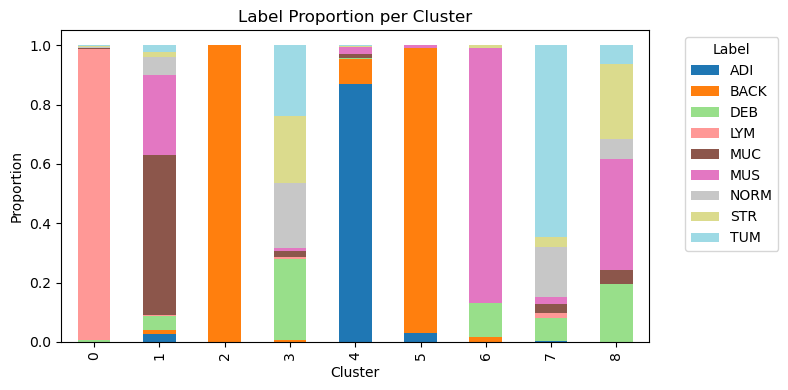

In [30]:
# Calculate the percentage of different labels within each cluster.
cluster_label_counts = pd.crosstab(clusters, labels, normalize='index')

# Draw a stacked bar chart
ax = cluster_label_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 4),
    colormap='tab20'
)

plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [51]:
kmeans_silhouette_pge = kmeans_silhouette
kmeans_v_measure_pge = kmeans_v_measure

<br>
<br>
<br>

## Apply to resnet50_umap_feature
<br>
<br>
<br>

Cluster 0: 612 samples
Cluster 1: 1626 samples
Cluster 2: 530 samples
Cluster 3: 105 samples
Cluster 4: 60 samples
Cluster 5: 866 samples
Cluster 6: 210 samples
Cluster 7: 846 samples
Cluster 8: 145 samples


D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


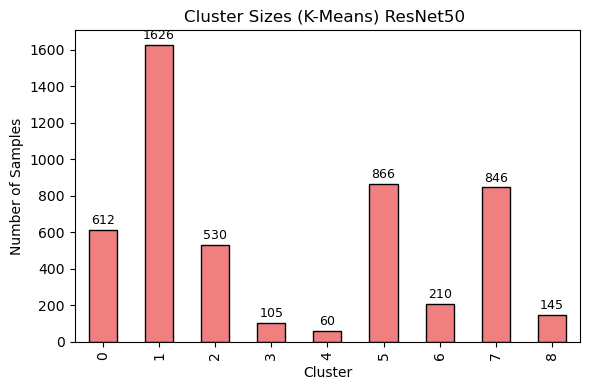

       Metric     Score
0  Silhouette  0.526835
1   V-measure  0.659527


In [48]:
# set number of clusters = 9
kmeans = KMeans(n_clusters=9, random_state=42)
clusters = kmeans.fit_predict(resnet50_umap_feature)

# Output the index of each cluster member
cluster_members = {i: np.where(clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Out put the number of members in each cluster
cluster_sizes = pd.Series(np.bincount(clusters))

ax = cluster_sizes.plot(
    kind='bar',
    color='lightcoral',
    edgecolor='black',
    figsize=(6, 4)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (K-Means) ResNet50 ")

for i, count in enumerate(cluster_sizes):
    ax.text(i, count + max(cluster_sizes)*0.01, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# evaluate measures
kmeans_silhouette = silhouette_score(resnet50_umap_feature, clusters)
kmeans_v_measure = v_measure_score(labels, clusters)

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [kmeans_silhouette, kmeans_v_measure]
})
print(metrics_df)


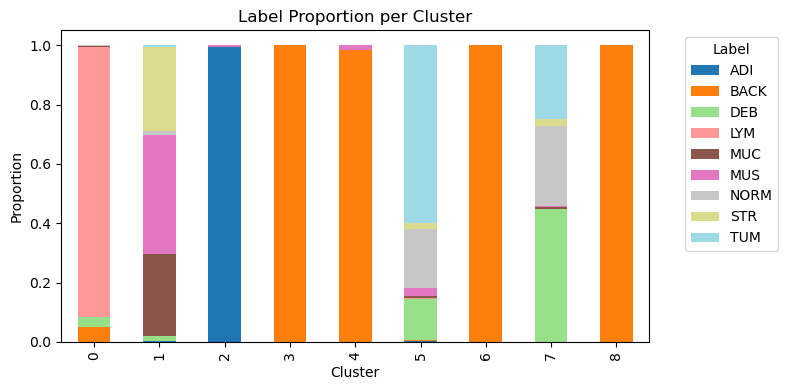

In [65]:
# Calculate the percentage of different labels within each cluster.
cluster_label_counts = pd.crosstab(clusters, labels, normalize='index')

# Draw a stacked bar chart
ax = cluster_label_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 4),
    colormap='tab20'
)

plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [49]:
kmeans_silhouette_resnet50 = kmeans_silhouette
kmeans_v_measure_resnet50 = kmeans_v_measure

<br>
<br>
<br>

## Apply to inceptionv3_pca_feature
<br>
<br>
<br>

Cluster 0: 413 samples
Cluster 1: 420 samples
Cluster 2: 410 samples
Cluster 3: 782 samples
Cluster 4: 350 samples
Cluster 5: 587 samples
Cluster 6: 425 samples
Cluster 7: 795 samples
Cluster 8: 818 samples


D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


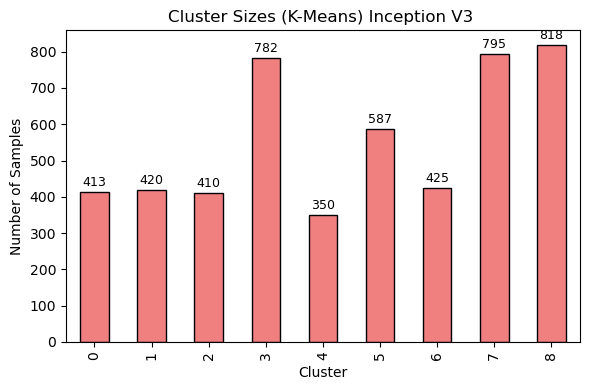

       Metric     Score
0  Silhouette  0.223733
1   V-measure  0.338945


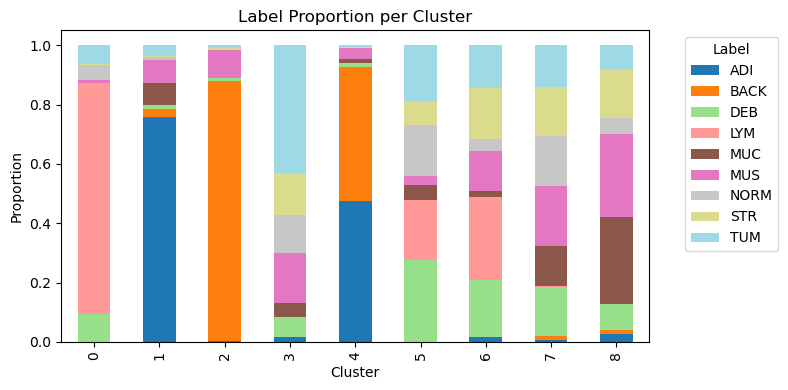

In [46]:
# set number of clusters = 9
kmeans = KMeans(n_clusters=9, random_state=42)
clusters = kmeans.fit_predict(inceptionv3_pca_feature)

# Output the index of each cluster member
cluster_members = {i: np.where(clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Out put the number of members in each cluster
cluster_sizes = pd.Series(np.bincount(clusters))

ax = cluster_sizes.plot(
    kind='bar',
    color='lightcoral',
    edgecolor='black',
    figsize=(6, 4)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (K-Means) Inception V3 ")

for i, count in enumerate(cluster_sizes):
    ax.text(i, count + max(cluster_sizes)*0.01, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# evaluate measures
kmeans_silhouette = silhouette_score(inceptionv3_pca_feature, clusters)
kmeans_v_measure = v_measure_score(labels, clusters)

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [kmeans_silhouette, kmeans_v_measure]
})
print(metrics_df)

# Calculate the percentage of different labels within each cluster.
cluster_label_counts = pd.crosstab(clusters, labels, normalize='index')

# Draw a stacked bar chart
ax = cluster_label_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 4),
    colormap='tab20'
)

plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [47]:
kmeans_silhouette_inceptionv3 = kmeans_silhouette
kmeans_v_measure_inceptionv3 = kmeans_v_measure

<br>
<br>
<br>

## Apply to vgg16_umap_feature
<br>
<br>
<br>

Cluster 0: 516 samples
Cluster 1: 1106 samples
Cluster 2: 531 samples
Cluster 3: 410 samples
Cluster 4: 901 samples
Cluster 5: 26 samples
Cluster 6: 869 samples
Cluster 7: 522 samples
Cluster 8: 119 samples


D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


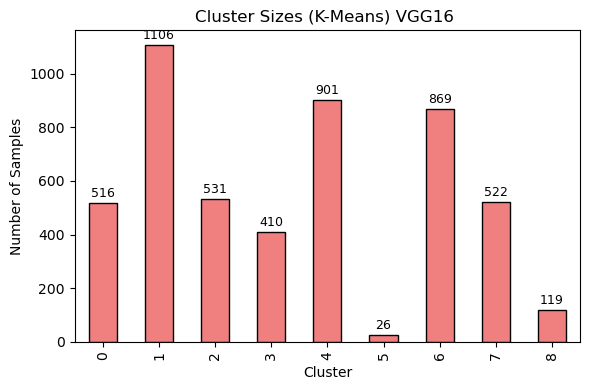

       Metric     Score
0  Silhouette  0.532692
1   V-measure  0.700790


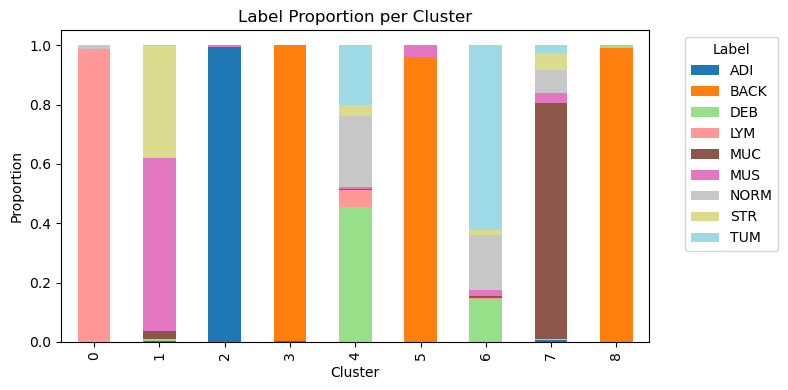

In [44]:
# set number of clusters = 9
kmeans = KMeans(n_clusters=9, random_state=42)
clusters = kmeans.fit_predict(vgg16_umap_feature)

# Output the index of each cluster member
cluster_members = {i: np.where(clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Out put the number of members in each cluster
cluster_sizes = pd.Series(np.bincount(clusters))

ax = cluster_sizes.plot(
    kind='bar',
    color='lightcoral',
    edgecolor='black',
    figsize=(6, 4)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (K-Means) VGG16 ")

for i, count in enumerate(cluster_sizes):
    ax.text(i, count + max(cluster_sizes)*0.01, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# evaluate measures
kmeans_silhouette = silhouette_score(vgg16_umap_feature, clusters)
kmeans_v_measure = v_measure_score(labels, clusters)

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [kmeans_silhouette, kmeans_v_measure]
})
print(metrics_df)

# Calculate the percentage of different labels within each cluster.
cluster_label_counts = pd.crosstab(clusters, labels, normalize='index')

# Draw a stacked bar chart
ax = cluster_label_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 4),
    colormap='tab20'
)

plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<br>
<br>

#### Store the silhouette and v-measure scores
<br>

In [45]:
kmeans_silhouette_vgg16 = kmeans_silhouette
kmeans_v_measure_vgg16 = kmeans_v_measure

In [56]:
print(f"kmeans_silhouette_pge:" ,kmeans_silhouette_pge)
print(f"kmeans_v_measure_pge:" ,kmeans_v_measure_pge)
print(f"kmeans_silhouette_resnet50:" ,kmeans_silhouette_resnet50)
print(f"kmeans_v_measure_resnet50:" ,kmeans_v_measure_resnet50)
print(f"kmeans_silhouette_inceptionv3:" ,kmeans_silhouette_inceptionv3)
print(f"kmeans_v_measure_inceptionv3:" ,kmeans_v_measure_inceptionv3)
print(f"kmeans_silhouette_vgg16:" ,kmeans_silhouette_vgg16)
print(f"kmeans_v_measure_vgg16:" ,kmeans_v_measure_vgg16)

kmeans_silhouette_pge: 0.5313033
kmeans_v_measure_pge: 0.5524259560417428
kmeans_silhouette_resnet50: 0.5268351
kmeans_v_measure_resnet50: 0.6595274285239442
kmeans_silhouette_inceptionv3: 0.2237327
kmeans_v_measure_inceptionv3: 0.3389448183217426
kmeans_silhouette_vgg16: 0.53269213
kmeans_v_measure_vgg16: 0.7007904344310123


# Gaussian Mixed Model

In [30]:
from sklearn.mixture import GaussianMixture

D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


Cluster 0: 551 samples
Cluster 1: 664 samples
Cluster 2: 386 samples
Cluster 3: 911 samples
Cluster 4: 605 samples
Cluster 5: 104 samples
Cluster 6: 121 samples
Cluster 7: 1067 samples
Cluster 8: 591 samples


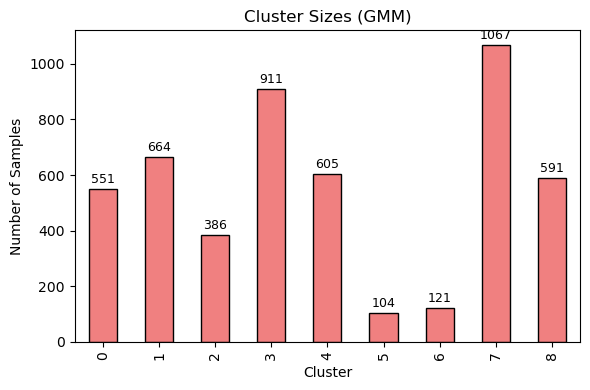

       Metric     Score
0  Silhouette  0.521919
1   V-measure  0.553939


In [57]:
# apply GMM clustering
gmm = GaussianMixture(n_components=9, random_state=42)
gmm_clusters = gmm.fit_predict(pge_umap_feature)

# Output the index of each cluster member
cluster_members = {i: np.where(gmm_clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Out put the number of members in each cluster
cluster_sizes = pd.Series(np.bincount(gmm_clusters))

ax = cluster_sizes.plot(
    kind='bar',
    color='lightcoral',
    edgecolor='black',
    figsize=(6, 4)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (GMM)")

for i, count in enumerate(cluster_sizes):
    ax.text(i, count + max(cluster_sizes)*0.01, str(count), ha='center', va='bottom', fontsize=9)


plt.tight_layout()
plt.show()

# Calculate evaluation measures and out put
GMM_silhouette = silhouette_score(pge_umap_feature, gmm_clusters)
GMM_v_measure = v_measure_score(labels, gmm_clusters)

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [GMM_silhouette, GMM_v_measure]
})
print(metrics_df)

<br>
<br>  
Calculate the percentage of different labels within each cluster. And out put bar chart.
<br>  
<br>   

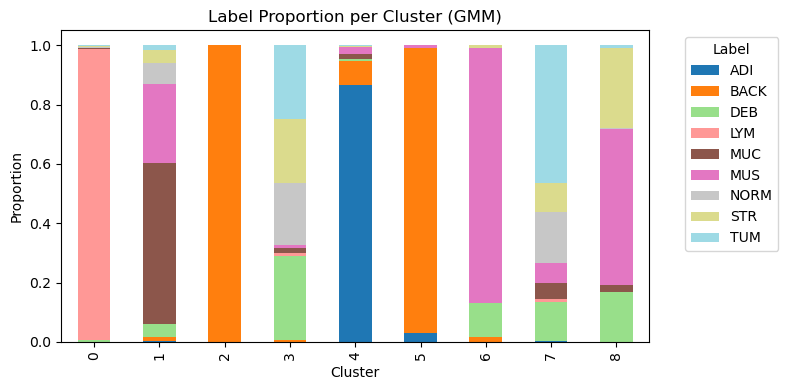

In [35]:
# Calculate the percentage of different labels within each cluster
cluster_label_counts = pd.crosstab(gmm_clusters, labels, normalize='index')

# Draw a stacked bar chart
ax = cluster_label_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 4),
    colormap='tab20'
)

plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster (GMM)")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [58]:
GMM_silhouette_pge = GMM_silhouette
GMM_v_measure_pge = GMM_v_measure

<br>
<br>
<br>

## Apply to resnet50_umap_feature
<br>
<br>
<br>

D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


Cluster 0: 612 samples
Cluster 1: 1624 samples
Cluster 2: 530 samples
Cluster 3: 105 samples
Cluster 4: 60 samples
Cluster 5: 880 samples
Cluster 6: 210 samples
Cluster 7: 834 samples
Cluster 8: 145 samples


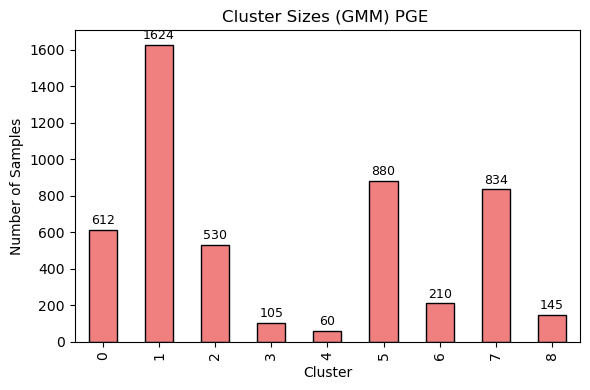

       Metric     Score
0  Silhouette  0.525000
1   V-measure  0.664004


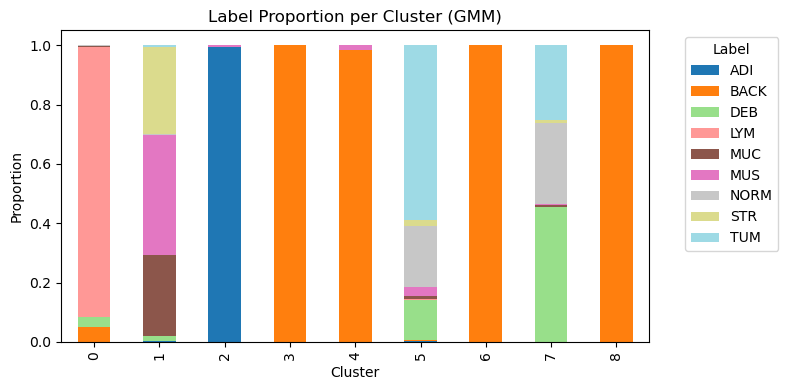

In [59]:
# apply GMM clustering
gmm = GaussianMixture(n_components=9, random_state=42)
gmm_clusters = gmm.fit_predict(resnet50_umap_feature)

# Output the index of each cluster member
cluster_members = {i: np.where(gmm_clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Out put the number of members in each cluster
cluster_sizes = pd.Series(np.bincount(gmm_clusters))

ax = cluster_sizes.plot(
    kind='bar',
    color='lightcoral',
    edgecolor='black',
    figsize=(6, 4)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (GMM) PGE ")

for i, count in enumerate(cluster_sizes):
    ax.text(i, count + max(cluster_sizes)*0.01, str(count), ha='center', va='bottom', fontsize=9)


plt.tight_layout()
plt.show()

# Calculate evaluation measures and out put
GMM_silhouette = silhouette_score(resnet50_umap_feature, gmm_clusters)
GMM_v_measure = v_measure_score(labels, gmm_clusters)

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [GMM_silhouette, GMM_v_measure]
})
print(metrics_df)

# Calculate the percentage of different labels within each cluster
cluster_label_counts = pd.crosstab(gmm_clusters, labels, normalize='index')

# Draw a stacked bar chart
ax = cluster_label_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 4),
    colormap='tab20'
)

plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster (GMM)")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [60]:
GMM_silhouette_resnet50 = GMM_silhouette
GMM_v_measure_resnet50 = GMM_v_measure

<br>
<br>
<br>

## Apply to inceptionv3_umap_feature
<br>
<br>
<br>

D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


Cluster 0: 426 samples
Cluster 1: 386 samples
Cluster 2: 330 samples
Cluster 3: 179 samples
Cluster 4: 857 samples
Cluster 5: 1518 samples
Cluster 6: 379 samples
Cluster 7: 335 samples
Cluster 8: 590 samples


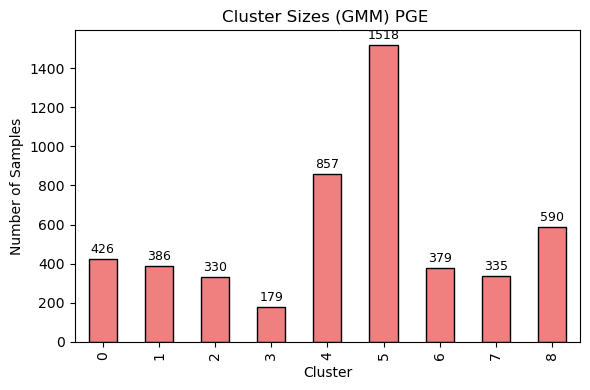

       Metric     Score
0  Silhouette  0.435106
1   V-measure  0.400642


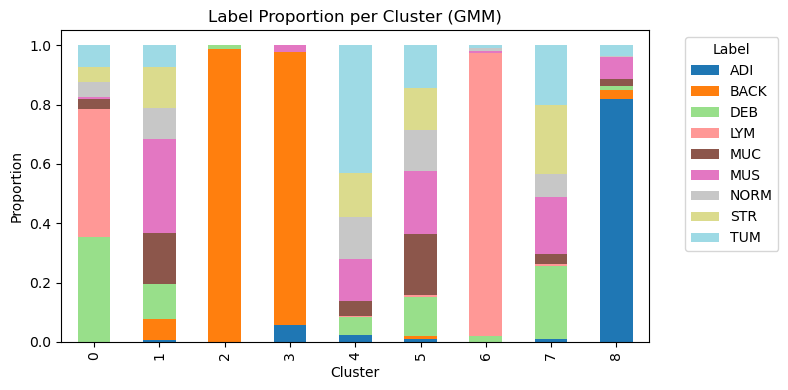

In [61]:
# apply GMM clustering
gmm = GaussianMixture(n_components=9, random_state=42)
gmm_clusters = gmm.fit_predict(inceptionv3_umap_feature)

# Output the index of each cluster member
cluster_members = {i: np.where(gmm_clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Out put the number of members in each cluster
cluster_sizes = pd.Series(np.bincount(gmm_clusters))

ax = cluster_sizes.plot(
    kind='bar',
    color='lightcoral',
    edgecolor='black',
    figsize=(6, 4)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (GMM) PGE ")

for i, count in enumerate(cluster_sizes):
    ax.text(i, count + max(cluster_sizes)*0.01, str(count), ha='center', va='bottom', fontsize=9)


plt.tight_layout()
plt.show()

# Calculate evaluation measures and out put
GMM_silhouette = silhouette_score(inceptionv3_umap_feature, gmm_clusters)
GMM_v_measure = v_measure_score(labels, gmm_clusters)

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [GMM_silhouette, GMM_v_measure]
})
print(metrics_df)

# Calculate the percentage of different labels within each cluster
cluster_label_counts = pd.crosstab(gmm_clusters, labels, normalize='index')

# Draw a stacked bar chart
ax = cluster_label_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 4),
    colormap='tab20'
)

plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster (GMM)")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [62]:
GMM_silhouette_inceptionv3 = GMM_silhouette
GMM_v_measure_inceptionv3 = GMM_v_measure

<br>
<br>
<br>

## Apply to vgg16_umap_feature
<br>
<br>
<br>

D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


Cluster 0: 516 samples
Cluster 1: 434 samples
Cluster 2: 531 samples
Cluster 3: 410 samples
Cluster 4: 551 samples
Cluster 5: 26 samples
Cluster 6: 1221 samples
Cluster 7: 1192 samples
Cluster 8: 119 samples


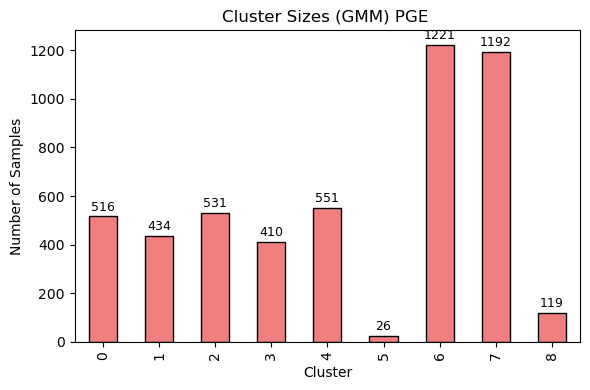

       Metric     Score
0  Silhouette  0.178872
1   V-measure  0.711401


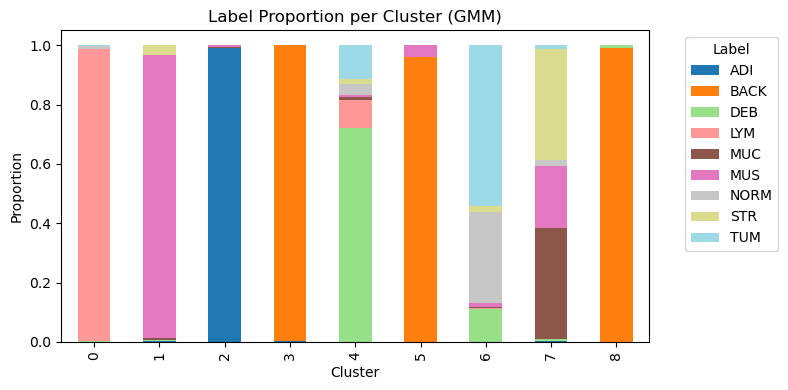

In [73]:
# apply GMM clustering
gmm = GaussianMixture(n_components=9, random_state=42)
gmm_clusters = gmm.fit_predict(vgg16_umap_feature)

# Output the index of each cluster member
cluster_members = {i: np.where(gmm_clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Out put the number of members in each cluster
cluster_sizes = pd.Series(np.bincount(gmm_clusters))

ax = cluster_sizes.plot(
    kind='bar',
    color='lightcoral',
    edgecolor='black',
    figsize=(6, 4)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (GMM) PGE ")

for i, count in enumerate(cluster_sizes):
    ax.text(i, count + max(cluster_sizes)*0.01, str(count), ha='center', va='bottom', fontsize=9)


plt.tight_layout()
plt.show()

# Calculate evaluation measures and out put
GMM_silhouette = silhouette_score(pge_umap_feature, gmm_clusters)
GMM_v_measure = v_measure_score(labels, gmm_clusters)

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [GMM_silhouette, GMM_v_measure]
})
print(metrics_df)

# Calculate the percentage of different labels within each cluster
cluster_label_counts = pd.crosstab(gmm_clusters, labels, normalize='index')

# Draw a stacked bar chart
ax = cluster_label_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 4),
    colormap='tab20'
)

plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster (GMM)")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [63]:
GMM_silhouette_vgg16 = GMM_silhouette
GMM_v_measure_vgg16 = GMM_v_measure

In [64]:
print(f"GMM_silhouette_pge:" ,GMM_silhouette_pge)
print(f"GMM_v_measure_pge:" ,GMM_v_measure_pge)
print(f"GMM_silhouette_resnet50:" ,GMM_silhouette_resnet50)
print(f"GMM_v_measure_resnet50:" ,GMM_v_measure_resnet50)
print(f"GMM_silhouette_inceptionv3:" ,GMM_silhouette_inceptionv3)
print(f"GMM_v_measure_inceptionv3:" ,GMM_v_measure_inceptionv3)
print(f"GMM_silhouette_vgg16:" ,GMM_silhouette_vgg16)
print(f"GMM_v_measure_vgg16:" ,GMM_v_measure_vgg16)

GMM_silhouette_pge: 0.5219193
GMM_v_measure_pge: 0.5539385767322794
GMM_silhouette_resnet50: 0.5249997
GMM_v_measure_resnet50: 0.6640039970570858
GMM_silhouette_inceptionv3: 0.43510616
GMM_v_measure_inceptionv3: 0.40064152451616475
GMM_silhouette_vgg16: 0.43510616
GMM_v_measure_vgg16: 0.40064152451616475


# Hierarchical Clustering

In [65]:
from sklearn.cluster import AgglomerativeClustering

Cluster 0: 976 samples
Cluster 1: 1342 samples
Cluster 2: 386 samples
Cluster 3: 613 samples
Cluster 4: 551 samples
Cluster 5: 104 samples
Cluster 6: 121 samples
Cluster 7: 592 samples
Cluster 8: 315 samples


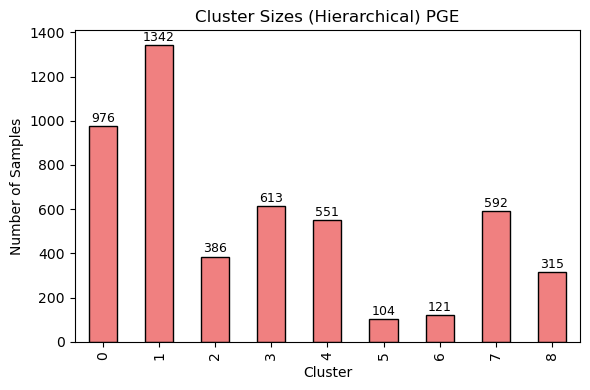

       Metric     Score
0  Silhouette  0.550981
1   V-measure  0.553202


In [66]:

# Perform Hierarchical Clustering (Agglomerative)
hc = AgglomerativeClustering(n_clusters=9)
hc_clusters = hc.fit_predict(pge_umap_feature)

# Calculate evaluation metrics with updated variable names
hierarchical_silhouette = silhouette_score(pge_umap_feature, hc_clusters)
hierarchical_v_measure = v_measure_score(labels, hc_clusters)

# Output the index of each cluster member
cluster_members = {i: np.where(hc_clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Plot cluster sizes with sample count annotations
cluster_sizes = pd.Series(np.bincount(hc_clusters))
ax = cluster_sizes.plot(kind='bar', color='lightcoral', edgecolor='black', figsize=(6, 4))
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (Hierarchical) PGE")

# Add text annotations on top of each bar
for i, count in enumerate(cluster_sizes):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [hierarchical_silhouette, hierarchical_v_measure]
})
print(metrics_df)


<br>
<br>  
Calculate the percentage of different labels within each cluster. And out put bar chart.
<br>  
<br>   

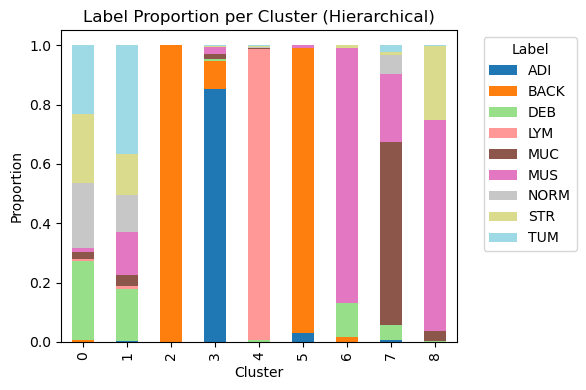

In [49]:
# Count label proportions within each cluster
cluster_label_counts = pd.crosstab(hc_clusters, labels, normalize='index')

# Plot stacked bar chart for label proportions
cluster_label_counts.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='tab20')
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster (Hierarchical)")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [67]:
hierarchical_silhouette_pge = hierarchical_silhouette
hierarchical_v_measure_pge = hierarchical_v_measure

<br>
<br>
<br>

## Apply to resnet50_umap_feature
<br>
<br>
<br>

Cluster 0: 202 samples
Cluster 1: 1131 samples
Cluster 2: 1641 samples
Cluster 3: 210 samples
Cluster 4: 530 samples
Cluster 5: 581 samples
Cluster 6: 566 samples
Cluster 7: 105 samples
Cluster 8: 34 samples


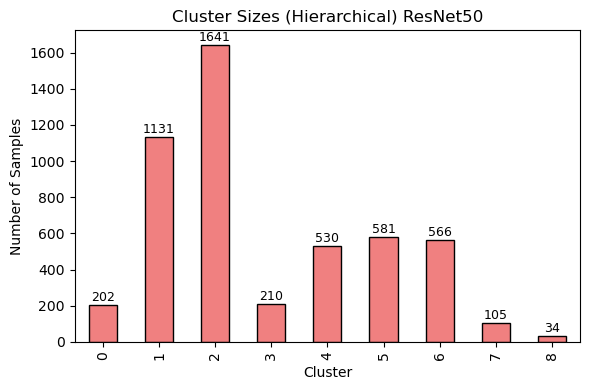

       Metric     Score
0  Silhouette  0.511764
1   V-measure  0.669291


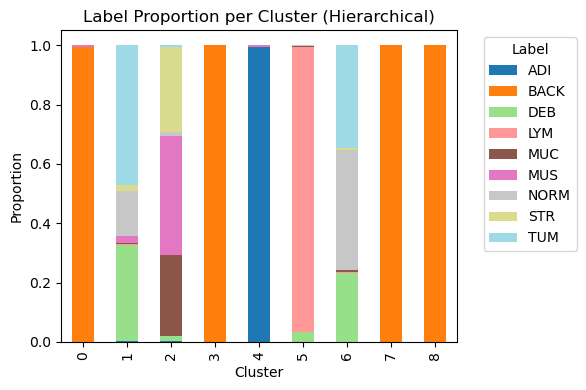

In [68]:
# Perform Hierarchical Clustering (Agglomerative)
hc = AgglomerativeClustering(n_clusters=9)
hc_clusters = hc.fit_predict(resnet50_umap_feature)

# Calculate evaluation metrics with updated variable names
hierarchical_silhouette = silhouette_score(resnet50_umap_feature, hc_clusters)
hierarchical_v_measure = v_measure_score(labels, hc_clusters)

# Output the index of each cluster member
cluster_members = {i: np.where(hc_clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Plot cluster sizes with sample count annotations
cluster_sizes = pd.Series(np.bincount(hc_clusters))
ax = cluster_sizes.plot(kind='bar', color='lightcoral', edgecolor='black', figsize=(6, 4))
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (Hierarchical) ResNet50")

# Add text annotations on top of each bar
for i, count in enumerate(cluster_sizes):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [hierarchical_silhouette, hierarchical_v_measure]
})
print(metrics_df)

# Count label proportions within each cluster
cluster_label_counts = pd.crosstab(hc_clusters, labels, normalize='index')

# Plot stacked bar chart for label proportions
cluster_label_counts.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='tab20')
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster (Hierarchical)")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [69]:
hierarchical_silhouette_resnet50 = hierarchical_silhouette
hierarchical_v_measure_resnet50 = hierarchical_v_measure

<br>
<br>
<br>

## Apply to vgg16_umap_feature
<br>
<br>
<br>

Cluster 0: 145 samples
Cluster 1: 858 samples
Cluster 2: 516 samples
Cluster 3: 577 samples
Cluster 4: 348 samples
Cluster 5: 1093 samples
Cluster 6: 870 samples
Cluster 7: 62 samples
Cluster 8: 531 samples


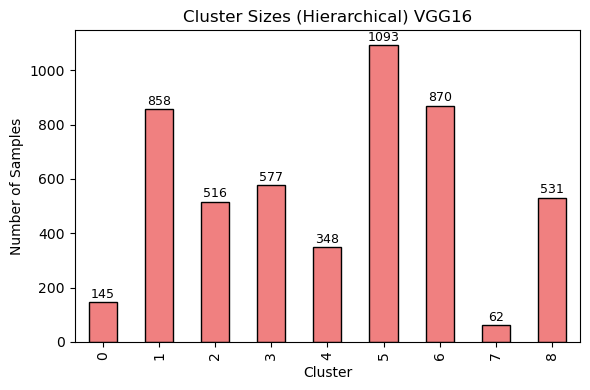

       Metric     Score
0  Silhouette  0.532340
1   V-measure  0.689708


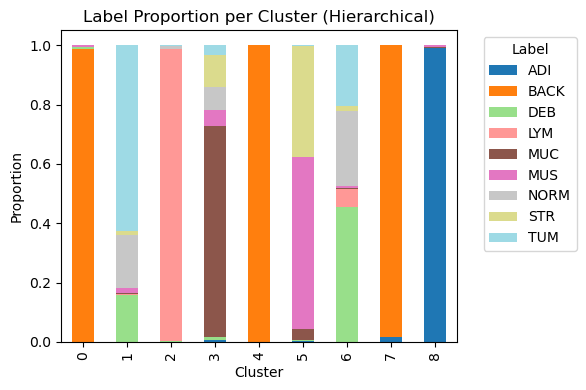

In [70]:
# Perform Hierarchical Clustering (Agglomerative)
hc = AgglomerativeClustering(n_clusters=9)
hc_clusters = hc.fit_predict(vgg16_umap_feature)

# Calculate evaluation metrics with updated variable names
hierarchical_silhouette = silhouette_score(vgg16_umap_feature, hc_clusters)
hierarchical_v_measure = v_measure_score(labels, hc_clusters)

# Output the index of each cluster member
cluster_members = {i: np.where(hc_clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Plot cluster sizes with sample count annotations
cluster_sizes = pd.Series(np.bincount(hc_clusters))
ax = cluster_sizes.plot(kind='bar', color='lightcoral', edgecolor='black', figsize=(6, 4))
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (Hierarchical) VGG16")

# Add text annotations on top of each bar
for i, count in enumerate(cluster_sizes):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [hierarchical_silhouette, hierarchical_v_measure]
})
print(metrics_df)

# Count label proportions within each cluster
cluster_label_counts = pd.crosstab(hc_clusters, labels, normalize='index')

# Plot stacked bar chart for label proportions
cluster_label_counts.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='tab20')
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster (Hierarchical)")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [71]:
hierarchical_silhouette_vgg16 = hierarchical_silhouette
hierarchical_v_measure_vgg16 = hierarchical_v_measure

<br>
<br>
<br>

## Apply to inceptionv3_pca_feature
<br>
<br>
<br>

Cluster 0: 896 samples
Cluster 1: 1054 samples
Cluster 2: 435 samples
Cluster 3: 445 samples
Cluster 4: 400 samples
Cluster 5: 291 samples
Cluster 6: 331 samples
Cluster 7: 744 samples
Cluster 8: 404 samples


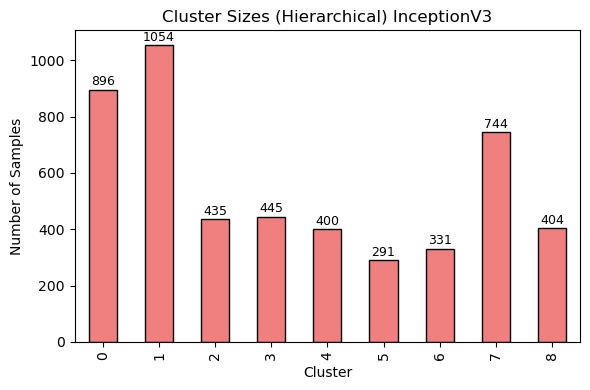

       Metric     Score
0  Silhouette  0.194385
1   V-measure  0.345102


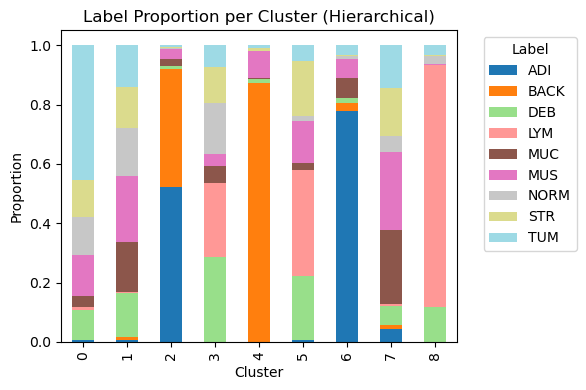

In [72]:
# Perform Hierarchical Clustering (Agglomerative)
hc = AgglomerativeClustering(n_clusters=9)
hc_clusters = hc.fit_predict(inceptionv3_pca_feature)

# Calculate evaluation metrics with updated variable names
hierarchical_silhouette = silhouette_score(inceptionv3_pca_feature, hc_clusters)
hierarchical_v_measure = v_measure_score(labels, hc_clusters)

# Output the index of each cluster member
cluster_members = {i: np.where(hc_clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Plot cluster sizes with sample count annotations
cluster_sizes = pd.Series(np.bincount(hc_clusters))
ax = cluster_sizes.plot(kind='bar', color='lightcoral', edgecolor='black', figsize=(6, 4))
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (Hierarchical) InceptionV3")

# Add text annotations on top of each bar
for i, count in enumerate(cluster_sizes):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [hierarchical_silhouette, hierarchical_v_measure]
})
print(metrics_df)

# Count label proportions within each cluster
cluster_label_counts = pd.crosstab(hc_clusters, labels, normalize='index')

# Plot stacked bar chart for label proportions
cluster_label_counts.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='tab20')
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster (Hierarchical)")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [73]:
hierarchical_silhouette_inceptionv3 = hierarchical_silhouette
hierarchical_v_measure_inceptionv3 = hierarchical_v_measure

In [74]:
print(f"hierarchical_silhouette_pge:" ,hierarchical_silhouette_pge)
print(f"hierarchical_v_measure_pge:" ,hierarchical_v_measure_pge)
print(f"hierarchical_silhouette_resnet50:" ,hierarchical_silhouette_resnet50)
print(f"hierarchical_v_measure_resnet50:" ,hierarchical_v_measure_resnet50)
print(f"hierarchical_silhouette_inceptionv3:" ,hierarchical_silhouette_inceptionv3)
print(f"hierarchical_v_measure_inceptionv3:" ,hierarchical_v_measure_inceptionv3)
print(f"hierarchical_silhouette_vgg16:" ,hierarchical_silhouette_vgg16)
print(f"hierarchical_v_measure_vgg16:" ,hierarchical_v_measure_vgg16)

hierarchical_silhouette_pge: 0.5509812
hierarchical_v_measure_pge: 0.5532017889656432
hierarchical_silhouette_resnet50: 0.511764
hierarchical_v_measure_resnet50: 0.6692905618479446
hierarchical_silhouette_inceptionv3: 0.19438496
hierarchical_v_measure_inceptionv3: 0.3451024139066446
hierarchical_silhouette_vgg16: 0.53233975
hierarchical_v_measure_vgg16: 0.6897075890035876


# Spectral Clustering

In [40]:
from sklearn.cluster import SpectralClustering

D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Cluster 0: 655 samples
Cluster 1: 810 samples
Cluster 2: 1232 samples
Cluster 3: 967 samples
Cluster 4: 386 samples
Cluster 5: 265 samples
Cluster 6: 96 samples
Cluster 7: 468 samples
Cluster 8: 121 samples


D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


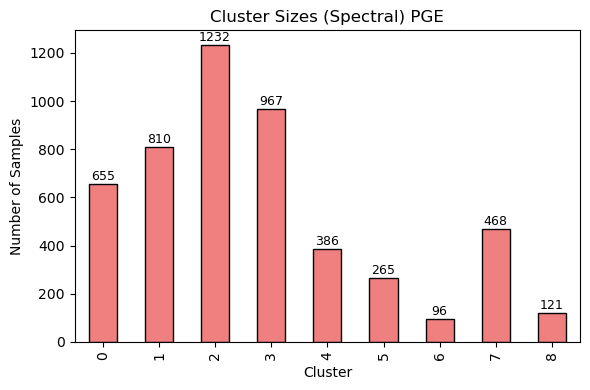

       Metric     Score
0  Silhouette  0.194385
1   V-measure  0.345102


In [91]:
# Perform Graph-based clustering (Spectral Clustering)
sc = SpectralClustering(n_clusters=9, random_state=42, affinity='nearest_neighbors', n_neighbors=25)
sc_clusters = sc.fit_predict(pge_umap_feature)

# Output the index of each cluster member
cluster_members = {i: np.where(sc_clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Plot cluster sizes with sample count annotations
cluster_sizes = pd.Series(np.bincount(sc_clusters))
ax = cluster_sizes.plot(kind='bar', color='lightcoral', edgecolor='black', figsize=(6, 4))
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (Spectral) PGE")

# Add text annotations on top of each bar
for i, count in enumerate(cluster_sizes):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Calculate evaluation metrics with updated variable names
spectral_silhouette = silhouette_score(pge_umap_feature, sc_clusters)
spectral_v_measure = v_measure_score(labels, sc_clusters)

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [hierarchical_silhouette, hierarchical_v_measure]
})
print(metrics_df)

<br>
<br>  
Calculate the percentage of different labels within each cluster. And out put bar chart.
<br>  
<br>   

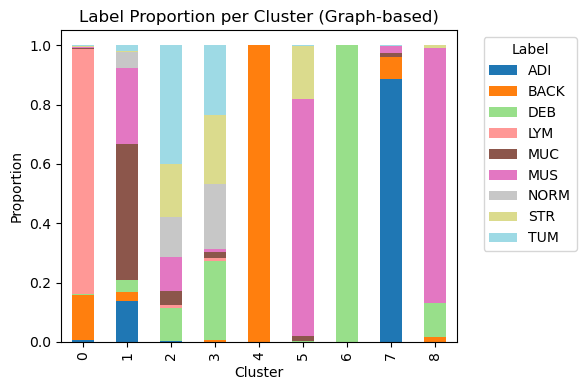

In [63]:
# Count label proportions within each cluster
cluster_label_counts = pd.crosstab(sc_clusters, labels, normalize='index')

# Plot stacked bar chart for label proportions
cluster_label_counts.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='tab20')
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster (Graph-based)")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [77]:
spectral_silhouette_pge = spectral_silhouette
spectral_v_measure_pge = spectral_v_measure

<br>
<br>
<br>

## Apply to resnet50_umap_feature
<br>
<br>
<br>

D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Cluster 0: 1698 samples
Cluster 1: 1265 samples
Cluster 2: 740 samples
Cluster 3: 608 samples
Cluster 4: 226 samples
Cluster 5: 54 samples
Cluster 6: 57 samples
Cluster 7: 26 samples
Cluster 8: 326 samples


D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


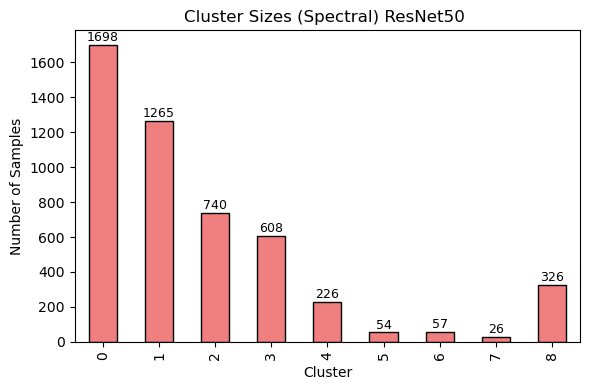

       Metric     Score
0  Silhouette  0.194385
1   V-measure  0.345102


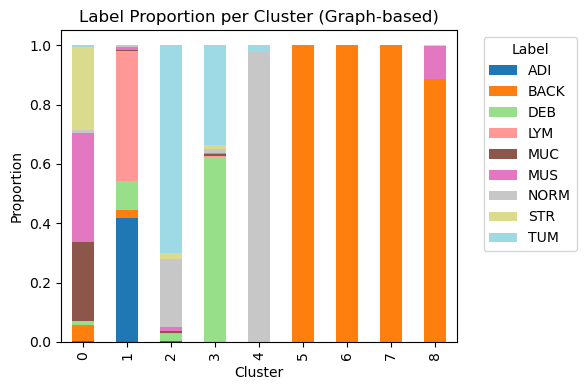

In [78]:
# Perform Graph-based clustering (Spectral Clustering)
sc = SpectralClustering(n_clusters=9, random_state=42, affinity='nearest_neighbors', n_neighbors=25)
sc_clusters = sc.fit_predict(resnet50_umap_feature)

# Output the index of each cluster member
cluster_members = {i: np.where(sc_clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Plot cluster sizes with sample count annotations
cluster_sizes = pd.Series(np.bincount(sc_clusters))
ax = cluster_sizes.plot(kind='bar', color='lightcoral', edgecolor='black', figsize=(6, 4))
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (Spectral) ResNet50 ")

# Add text annotations on top of each bar
for i, count in enumerate(cluster_sizes):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Calculate evaluation metrics with updated variable names
spectral_silhouette = silhouette_score(resnet50_umap_feature, sc_clusters)
spectral_v_measure = v_measure_score(labels, sc_clusters)

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [hierarchical_silhouette, hierarchical_v_measure]
})
print(metrics_df)

# Count label proportions within each cluster
cluster_label_counts = pd.crosstab(sc_clusters, labels, normalize='index')

# Plot stacked bar chart for label proportions
cluster_label_counts.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='tab20')
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster (Graph-based)")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [79]:
spectral_silhouette_resnet50 = spectral_silhouette
spectral_v_measure_resnet50 = spectral_v_measure

<br>
<br>
<br>

## Apply to inceptionv3_umap_feature
<br>
<br>
<br>

D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Cluster 0: 125 samples
Cluster 1: 1282 samples
Cluster 2: 1755 samples
Cluster 3: 146 samples
Cluster 4: 330 samples
Cluster 5: 554 samples
Cluster 6: 66 samples
Cluster 7: 340 samples
Cluster 8: 402 samples


D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


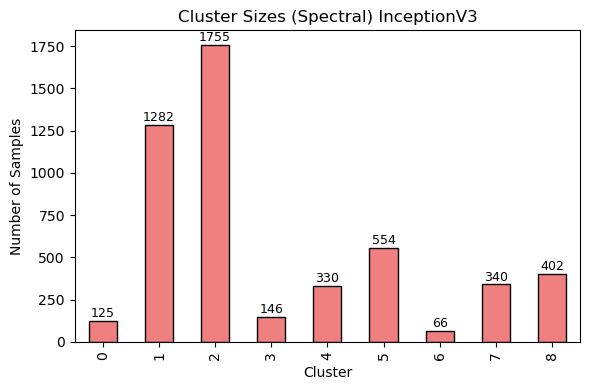

       Metric     Score
0  Silhouette  0.194385
1   V-measure  0.345102


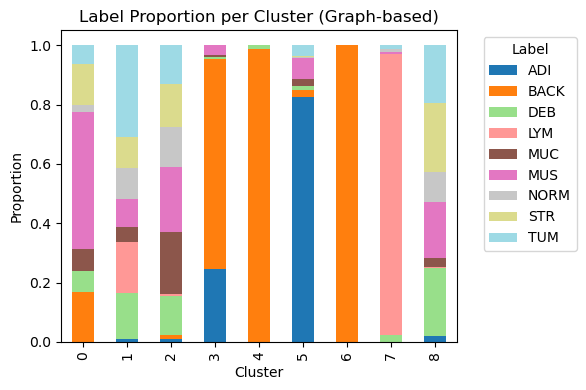

In [80]:
# Perform Graph-based clustering (Spectral Clustering)
sc = SpectralClustering(n_clusters=9, random_state=42, affinity='nearest_neighbors', n_neighbors=25)
sc_clusters = sc.fit_predict(inceptionv3_umap_feature)

# Output the index of each cluster member
cluster_members = {i: np.where(sc_clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Plot cluster sizes with sample count annotations
cluster_sizes = pd.Series(np.bincount(sc_clusters))
ax = cluster_sizes.plot(kind='bar', color='lightcoral', edgecolor='black', figsize=(6, 4))
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (Spectral) InceptionV3")

# Add text annotations on top of each bar
for i, count in enumerate(cluster_sizes):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Calculate evaluation metrics with updated variable names
spectral_silhouette = silhouette_score(inceptionv3_umap_feature, sc_clusters)
spectral_v_measure = v_measure_score(labels, sc_clusters)

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [hierarchical_silhouette, hierarchical_v_measure]
})
print(metrics_df)

# Count label proportions within each cluster
cluster_label_counts = pd.crosstab(sc_clusters, labels, normalize='index')

# Plot stacked bar chart for label proportions
cluster_label_counts.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='tab20')
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster (Graph-based)")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [81]:
spectral_silhouette_inceptionv3 = spectral_silhouette
spectral_v_measure_inceptionv3 = spectral_v_measure

<br>
<br>
<br>

## Apply to vgg16_umap_feature
<br>
<br>
<br>

D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Cluster 0: 1465 samples
Cluster 1: 26 samples
Cluster 2: 2659 samples
Cluster 3: 84 samples
Cluster 4: 123 samples
Cluster 5: 348 samples
Cluster 6: 99 samples
Cluster 7: 134 samples
Cluster 8: 62 samples


D:\Program Files\Anaconda 3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


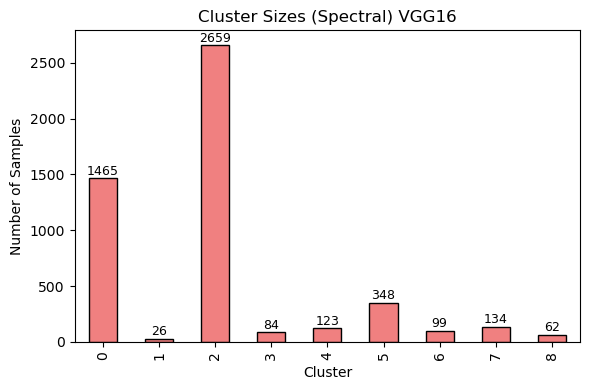

       Metric     Score
0  Silhouette  0.194385
1   V-measure  0.345102


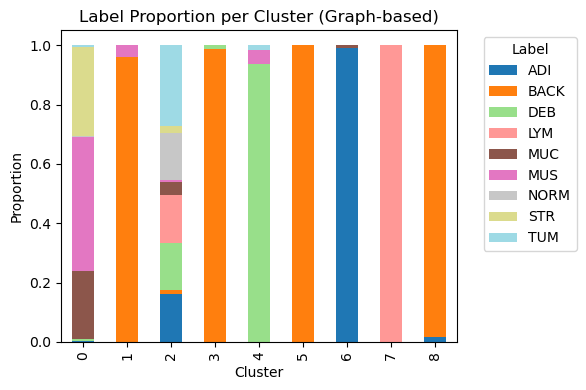

In [82]:
# Perform Graph-based clustering (Spectral Clustering)
sc = SpectralClustering(n_clusters=9, random_state=42, affinity='nearest_neighbors', n_neighbors=25)
sc_clusters = sc.fit_predict(vgg16_umap_feature)

# Output the index of each cluster member
cluster_members = {i: np.where(sc_clusters == i)[0] for i in range(9)}
for cluster_id, members in cluster_members.items():
    print(f"Cluster {cluster_id}: {len(members)} samples")

# Plot cluster sizes with sample count annotations
cluster_sizes = pd.Series(np.bincount(sc_clusters))
ax = cluster_sizes.plot(kind='bar', color='lightcoral', edgecolor='black', figsize=(6, 4))
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sizes (Spectral) VGG16")

# Add text annotations on top of each bar
for i, count in enumerate(cluster_sizes):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Calculate evaluation metrics with updated variable names
spectral_silhouette = silhouette_score(vgg16_umap_feature, sc_clusters)
spectral_v_measure = v_measure_score(labels, sc_clusters)

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette", "V-measure"],
    "Score": [hierarchical_silhouette, hierarchical_v_measure]
})
print(metrics_df)

# Count label proportions within each cluster
cluster_label_counts = pd.crosstab(sc_clusters, labels, normalize='index')

# Plot stacked bar chart for label proportions
cluster_label_counts.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='tab20')
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.title("Label Proportion per Cluster (Graph-based)")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [83]:
spectral_silhouette_vgg16 = spectral_silhouette
spectral_v_measure_vgg16 = spectral_v_measure

In [84]:
print(f"spectral_silhouette_pge:" ,spectral_silhouette_pge)
print(f"spectral_v_measure_pge:" ,spectral_v_measure_pge)
print(f"spectral_silhouette_resnet50:" ,spectral_silhouette_resnet50)
print(f"spectral_v_measure_resnet50:" ,spectral_v_measure_resnet50)
print(f"spectral_silhouette_inceptionv3:" ,spectral_silhouette_inceptionv3)
print(f"spectral_v_measure_inceptionv3:" ,spectral_v_measure_inceptionv3)
print(f"spectral_silhouette_vgg16:" ,spectral_silhouette_vgg16)
print(f"spectral_v_measure_vgg16:" ,spectral_v_measure_vgg16)

spectral_silhouette_pge: 0.51664126
spectral_v_measure_pge: 0.5184734172549107
spectral_silhouette_resnet50: 0.19691655
spectral_v_measure_resnet50: 0.5960787345348996
spectral_silhouette_inceptionv3: 0.41601717
spectral_v_measure_inceptionv3: 0.3744853759636885
spectral_silhouette_vgg16: 0.10078074
spectral_v_measure_vgg16: 0.48783132726147665


# Create tables of comparision of socres of different evaluate measures in different clustering methods

This part is going to create 2 4*4 table. One is about silhouette, the other is about v-measure.

## 1 - Silhouette score comparison

In [89]:
scores = {
    "KMeans": {
        "pge": kmeans_silhouette_pge,
        "resnet50": kmeans_silhouette_resnet50,
        "inceptionv3": kmeans_silhouette_inceptionv3,
        "vgg16": kmeans_silhouette_vgg16
    },
    "GMM": {
        "pge": GMM_silhouette_pge,
        "resnet50": GMM_silhouette_resnet50,
        "inceptionv3": GMM_silhouette_inceptionv3,
        "vgg16": GMM_silhouette_vgg16
    },
    "Hierarchical": {
        "pge": hierarchical_silhouette_pge,
        "resnet50": hierarchical_silhouette_resnet50,
        "inceptionv3": hierarchical_silhouette_inceptionv3,
        "vgg16": hierarchical_silhouette_vgg16
    },
    "Spectral": {
        "pge": spectral_silhouette_pge,
        "resnet50": spectral_silhouette_resnet50,
        "inceptionv3": spectral_silhouette_inceptionv3,
        "vgg16": spectral_silhouette_vgg16
    }
}

# Convert to DataFrame
df = pd.DataFrame(scores)
print('Silhouette')
print(df)

Silhouette
               KMeans       GMM  Hierarchical  Spectral
pge          0.531303  0.521919      0.550981  0.516641
resnet50     0.526835  0.525000      0.511764  0.196917
inceptionv3  0.223733  0.435106      0.194385  0.416017
vgg16        0.532692  0.435106      0.532340  0.100781


## 2 - V-measure score comparison

In [90]:
v_measure = {
    "KMeans": {
        "pge": kmeans_v_measure_pge,
        "resnet50": kmeans_v_measure_resnet50,
        "inceptionv3": kmeans_v_measure_inceptionv3,
        "vgg16": kmeans_v_measure_vgg16
    },
    "GMM": {
        "pge": GMM_v_measure_pge,
        "resnet50": GMM_v_measure_resnet50,
        "inceptionv3": GMM_v_measure_inceptionv3,
        "vgg16": GMM_v_measure_vgg16
    },
    "Hierarchical": {
        "pge": hierarchical_v_measure_pge,
        "resnet50": hierarchical_v_measure_resnet50,
        "inceptionv3": hierarchical_v_measure_inceptionv3,
        "vgg16": hierarchical_v_measure_vgg16
    },
    "Spectral": {
        "pge": spectral_v_measure_pge,
        "resnet50": spectral_v_measure_resnet50,
        "inceptionv3": spectral_v_measure_inceptionv3,
        "vgg16": spectral_v_measure_vgg16
    }
}

# Convert to DataFrame
df = pd.DataFrame(v_measure)
print('V-measure')
print(df)

V-measure
               KMeans       GMM  Hierarchical  Spectral
pge          0.552426  0.553939      0.553202  0.518473
resnet50     0.659527  0.664004      0.669291  0.596079
inceptionv3  0.338945  0.400642      0.345102  0.374485
vgg16        0.700790  0.400642      0.689708  0.487831
